In [8]:
import os
import sys
import cvxpy as cp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath('..'))

from src.models.battery_storage import BatteryStorage
from src.models.building_load import BuildingLoad
from src.models.pv_generator import PVGenerator

In [43]:
#run optimization for one day 
centerHall = BuildingLoad(name="CenterHall")
hopkinsParkingPV = PVGenerator(name="HopkinsParkingPV")
batterystorage = BatteryStorage(name="BatteryStorage")

start = "2016-01-08"
end = "2016-01-09"

load_df = centerHall.get_data(start, end)
pv_df = hopkinsParkingPV.get_data(start, end)
#set all the negatve values in pv_df to 0
load = load_df['RealPower'].values
pv = pv_df['RealPower'].clip(lower=0)

T = len(load)  #should be 24 for one day 

# example price array 
price = np.array([
    40, 40, 35, 30, 30, 35,
    50, 70, 90, 100, 120, 150,
    140, 120, 110, 100, 90, 80,
    70, 60, 50, 45, 40, 40
])  

grid_import  = cp.Variable(T) 
#negative for dischagring, positive for charging 
battery_power = cp.Variable(T)
SOC = cp.Variable(T+1) # initial SOC + T time steps

constraints = []
 # initial SOC at 50%
constraints += [SOC[0] == batterystorage.rating_kwh * 0.5] 
# Energy balance for storage SOC at beginging of day = SOC at end of day 
constraints += [SOC[-1] == SOC[0]]
#at each time step the SOC is updated based on charge and discharge(already negative)
#TODO: update with  battery efficiency 
constraints += [SOC[1:] == (SOC[:-1] + battery_power * 0.95)]
#battery ratings 
constraints += [SOC >= 0, SOC <= batterystorage.rating_kwh]
#discharge negative kW, charge positive kW
constraints += [battery_power  >= -batterystorage.rating_kw, battery_power <= batterystorage.rating_kw]
#energy balance of grid 
constraints += [grid_import == load + battery_power - pv]
constraints += [grid_import >= 0]

objective = cp.Minimize(cp.sum(cp.multiply(grid_import, price)))

prob = cp.Problem(objective, constraints)
prob.solve()

print("Optimal cost:", prob.value)

Optimal cost: 65123.73001813181


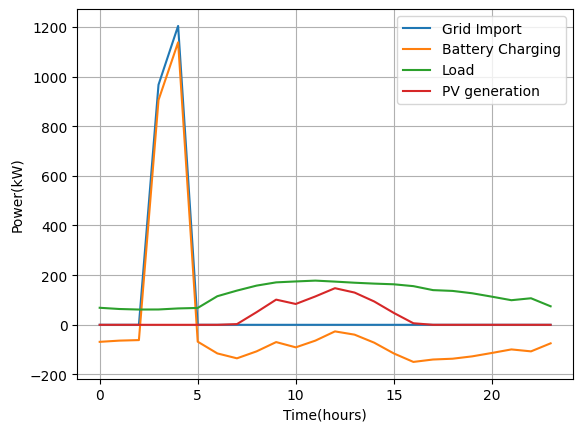

In [36]:
# creates an np array from 0-23 24 timestamps 
time = np.arange(T)

plt.plot(time, grid_import.value, label="Grid Import")
plt.plot(time, battery_power.value, label="Battery Charging")
plt.plot(time, load, label="Load")
plt.plot(time, pv, label="PV generation")

plt.xlabel("Time(hours)")
plt.ylabel("Power(kW)")
plt.grid()
plt.legend()

plt.show()